# Module 7 bis - Klaro - Notebook de pilotage

Ce notebook deroule le brief en binome : l'ancienne architecture, puis les
4 agents (2 par apprenant), tous bases sur un vrai modele Mistral. Aucune
generation de donnees : tout est statique dans `data/`.

Les TODO se trouvent dans les fichiers `src/agent/agent*.py`, pas dans ce
notebook : les cellules ci-dessous appellent simplement `repondre(...)` /
`executer_agent4(...)`, deja fournis. Tant qu'un agent n'est pas termine,
la cellule correspondante leve `NotImplementedError`.

> Avant de commencer : copiez `.env.example` en `.env` et renseignez
> `MISTRAL_API_KEY` (voir `README.md`). Chaque cellule ci-dessous declenche
> un ou plusieurs appels API reels.

## Bootstrap - remonter a la racine du projet

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config as C, data as D
from src.agent.ancien_bot import repondre_ancien_bot
from src.agent.tools import ContexteOutils
from src.agent import agent1_renseignement as A1
from src.agent import agent2_remboursement as A2
from src.agent import agent3_pretriage as A3
from src.agent import agent4_autonomie as A4
print("Racine:", ROOT)

Racine: /home/amina/M7B_Klaro_Squelette


In [2]:
import os
if not os.environ.get("MISTRAL_API_KEY"):
    print("MISTRAL_API_KEY absente : copiez .env.example en .env et renseignez votre cle "
         "(https://console.mistral.ai/) avant d'executer les cellules suivantes.")
else:
    print("MISTRAL_API_KEY detectee.")

MISTRAL_API_KEY detectee.


## Chargement des donnees

In [3]:
faq = D.charger_faq()
commandes = D.charger_commandes()
tickets = D.charger_tickets()
messages = D.charger_messages()
len(faq), len(commandes), len(tickets), len(messages)

(20, 45, 18, 50)

<h2 style="color:red;">Les données

In [20]:
faq.head()

,id,categorie,question,reponse
0,F01,livraison,Quel est le délai de livraison standard ?,La livraison standard prend entre 3 et 5 jours...
1,F02,livraison,Comment suivre ma commande ?,Le numéro de suivi est envoyé par email dès l'...
2,F03,livraison,"Ma commande est en retard, que faire ?",Si la date de livraison prévue est dépassée de...
3,F04,livraison,Puis-je changer l'adresse de livraison après c...,L'adresse peut être modifiée uniquement si la ...
4,F05,retour_remboursement,Quel est le délai pour retourner un produit ?,Vous disposez de 14 jours après réception pour...


<p style="color: #610BF4;">
faq.json contient les questions/réponses générales pour aider les clients.
</p>

In [21]:
commandes.head()

,commande_id,client_id,produit,montant_eur,date_commande,statut,date_livraison_prevue,date_livraison_reelle
0,CMD-1001,CLI-0031,Aspirateur sans fil X200,189.9,2026-02-20,livree,2026-02-24,2026-02-24
1,CMD-1002,CLI-0012,Lampe de bureau LED,34.5,2026-03-05,livree,2026-03-09,2026-03-08
2,CMD-1003,CLI-0077,Cafetiere programmable,59.9,2026-01-10,livree,2026-01-14,2026-01-15
3,CMD-1004,CLI-0004,Plaid polaire,24.9,2026-03-10,livree,2026-03-13,2026-03-13
4,CMD-1005,CLI-0056,Enceinte bluetooth Sona,79.0,2026-02-01,livree,2026-02-05,2026-02-06


<p style="color: #610BF4;">
commandes.csv contient les informations sur les commandes.
</p>

In [19]:
tickets.head()

,ticket_id,date,sujet,resolution
0,T-501,2026-01-08,Aspirateur X200 bruit anormal,Echange standard accepte hors delai car defaut...
1,T-502,2026-01-12,Retard livraison trottinette Urban,Ouverture reclamation transporteur rembourseme...
2,T-503,2026-01-15,Double debit carte bancaire,Remboursement du doublon sous 48h apres verifi...
3,T-504,2026-01-20,Robot patissier piece manquante,Envoi de la piece manquante sans nouvelle comm...
4,T-505,2026-01-25,Demande suppression compte RGPD,Suppression effectuee sous 30 jours conformeme...


<p style="color: #610BF4;">
tickets_historique.csv contient des anciens tickets déjà traités
</p>

In [16]:
messages.head()

,message_id,date,texte,_categorie_vraie,_ambigu
0,M-001,2026-03-14,Bonjour ma commande CMD-1013 devait arriver le...,livraison,0
1,M-002,2026-03-14,Je souhaite retourner mon aspirateur il ne me ...,retour_remboursement,0
2,M-003,2026-03-14,Impossible de me connecter a mon compte le mot...,compte,0
3,M-004,2026-03-13,Est ce que la chaise de bureau supporte plus d...,produit,0
4,M-005,2026-03-13,J'ai ete debite deux fois pour la meme command...,paiement,0


<p style="color: #610BF4;">
messages_entrants.csv contient les nouveaux messages envoyés par les clients.
</p>

## Etape 1 - L'ancienne architecture (a evaluer, en binome)

Pas de code a completer ici : executez l'ancien bot sur quelques questions,
observez ses limites, et redigez a deux la note d'architecture et de risques
(livrable ecrit, voir le brief). C'est aussi ici que vous vous repartissez
les agents 1 a 4.

```mermaid
%%{init: {
  "themeVariables": {
    "fontSize": "14px"
  },
  "flowchart": {
    "nodeSpacing": 50,
    "rankSpacing": 55,
    "htmlLabels": true
  }
}}%%

flowchart TD

    A([Début]) --> B[Le client pose une question]

    B --> C[repondre_ancien_bot question]

    C --> D[Mettre la question en minuscules<br/>question.lower]

    D --> E[Parcourir les mots-clés<br/>de _REPONSES]

    E --> F{Mot-clé trouvé ?}

    F -->|Oui| G[Prendre la réponse fixe<br/>associée au mot-clé]

    F -->|Non| H[Réponse par défaut :<br/>Je n'ai pas compris votre demande]

    G --> I[Envoyer la réponse au client]
    H --> I

    I --> J([Fin])

    classDef bleu fill:#eef5ff,stroke:#2f6fed,color:#1f4fa3,stroke-width:2px;

    class A,B,C,D,E,F,G,H,I,J bleu;

In [4]:
for q in ["Ou en est ma commande CMD-1013 ?",
         "Je veux etre rembourse pour la commande CMD-1007"]:
    print("Q:", q)
    print("R (ancien bot):", repondre_ancien_bot(q))
    print()

Q: Ou en est ma commande CMD-1013 ?
R (ancien bot): Je n'ai pas compris votre demande, un conseiller vous recontactera.

Q: Je veux etre rembourse pour la commande CMD-1007
R (ancien bot): Pas de souci, vous serez rembourse sous peu !



<h2 style="color:red;"> L'ancienne architecture - Test avec d'autres questions</h2>

In [5]:
questions = [
    "Quel est le delai pour retourner un produit ?",
    "Ma carte a ete debitee deux fois, que faire ?",
    "Je souhaite retourner mon aspirateur il ne me convient pas comment faire",
]

for q in questions:
    print("Q:", q)
    print("R (ancien bot):", repondre_ancien_bot(q))
    print()

Q: Quel est le delai pour retourner un produit ?
R (ancien bot): Pas de souci, vous serez rembourse sous peu !

Q: Ma carte a ete debitee deux fois, que faire ?
R (ancien bot): Je n'ai pas compris votre demande, un conseiller vous recontactera.

Q: Je souhaite retourner mon aspirateur il ne me convient pas comment faire
R (ancien bot): Pas de souci, vous serez rembourse sous peu !





## Défauts observés de l'ancien bot

- Il comprend mal le contexte de la demande (il fonctionne principalement avec des mots-clés)
- il ne consulte pas les vraies données du projet, donc il ne peut pas vérifier correctement une commande ou une situation client.
-  Il peut aussi annoncer un remboursement sans vérifier si la commande est réellement éligible. 
- Il peut alors donner une mauvaise réponse, par exemple confondre une demande de retour avec un remboursement.   
- certaines demandes ne sont pas reconnues du tout, comme le cas d’un double débit de carte.

##  Nouvelle architecture

| Agent | Rôle | Données / outils principaux |
|---|---|---|
| Agent 1 | Renseignement général | FAQ + commandes |
| Agent 2 | Vérification remboursement | Éligibilité + historique |
| Agent 3 | Pré-triage des messages | Messages entrants |
| Agent 4 | Remboursement sous contrôle | Éligibilité + outil de remboursement |

## Agent 1 - Renseignement general

FAQ + suivi de commande. 2 outils : `chercher_faq`, `consulter_commande`.
TODO dans `src/agent/agent1_renseignement.py` : `construire_agent`.

```mermaid
%%{init: {
  "themeVariables": {
    "fontSize": "14px"
  },
  "flowchart": {
    "nodeSpacing": 50,
    "rankSpacing": 55,
    "htmlLabels": true
  }
}}%%

flowchart TD

    A([Début]) --> B[Le client pose une question]

    B --> C[Agent 1 : renseignement général]

    C --> D[Modèle Mistral]

    D --> E{Quel type de question ?}

    E -->|Question générale| F[Appel de chercher_faq]

    E -->|Numéro de commande| G[Appel de consulter_commande]

    F --> H[Lecture de faq.json]

    G --> I[Lecture de commandes.csv]

    H --> J[Résultat de l'outil]

    I --> J

    J --> K[Mistral construit la réponse<br/>à partir du résultat]

    K --> L[Réponse au client]

    L --> M[Trace de l'appel d'outil]

    M --> N([Fin])

    classDef bleu fill:#eef5ff,stroke:#2f6fed,color:#1f4fa3,stroke-width:2px;

    class A,B,C,D,E,F,G,H,I,J,K,L,M,N bleu;

In [6]:
ctx = ContexteOutils(faq=faq, commandes=commandes, tickets=tickets)

for q in ["Ou en est ma commande CMD-1013 ?", "Quel est le delai de livraison standard ?"]:
    res = A1.repondre(ctx, q)
    print("Q:", q)
    print("R:", res["diagnostic"]["reponse"])
    print()

Q: Ou en est ma commande CMD-1013 ?
R: Votre commande **CMD-1013** pour l'**enceinte Bluetooth Sona** (montant de **79,00 €**) est actuellement **en retard**.

- **Date de commande** : 10 février 2026
- **Date de livraison prévue initialement** : 14 février 2026
- **Délai non encore respecté** : Aucune date de livraison réelle n'est encore confirmée.

Je vous tiens informé des mises à jour. Si vous avez besoin d'une assistance supplémentaire, n'hésitez pas à demander.

Q: Quel est le delai de livraison standard ?
R: Le délai de livraison standard pour une commande Klaro est généralement de **3 à 5 jours ouvrés** à compter de la validation de la commande.

Si vous avez besoin d'informations spécifiques sur une commande, n'hésitez pas à me fournir son numéro.



<h2 style="color:blue;">Agent 1 - Test avec d'autres questions</h2>

In [7]:
ctx = ContexteOutils(faq=faq, commandes=commandes, tickets=tickets)

for q in [
    "Comment suivre ma commande ?",
    "Ma commande est en retard, que faire ?",
    "Puis-je changer l'adresse de livraison après commande ?",
    "Comment réinitialiser mon mot de passe ?",
    "Ou en est ma commande CMD-1011 ?"
]:
    res = A1.repondre(ctx, q)
    print("Q:", q)
    print("R:", res["diagnostic"]["reponse"])
    print()

Q: Comment suivre ma commande ?
R: Voici comment suivre votre commande :

Le numéro de suivi vous est envoyé par email dès que votre commande est expédiée. Vous pouvez également le consulter directement dans votre **espace client**, sous la rubrique **"Mes commandes"**.

Si vous avez besoin d'aide supplémentaire, n'hésitez pas à demander !

Q: Ma commande est en retard, que faire ?
R: Si votre commande est en retard de plus de 3 jours par rapport à la date de livraison prévue, je vous recommande de **contacter le service client Klaro** en fournissant le **numéro de commande**. Ils pourront ouvrir une réclamation auprès du transporteur pour vous accompagner dans cette situation.

Si vous avez besoin d'aide pour trouver votre numéro de commande ou d'autres informations, n'hésitez pas à me le demander !

Q: Puis-je changer l'adresse de livraison après commande ?
R: Oui, vous pouvez changer l'adresse de livraison **uniquement si votre commande est encore en préparation**. Une fois que la c

| Point vérifié | Problème observé | Statut |
|---|---|---|
| Agent 1 - `CMD-1011` | La réponse affiche des dates en 2024 alors que le scénario utilise des données 2026. |  À corriger |


## Agent 2 - Remboursement

Verifie l'eligibilite, ne rembourse jamais seul (pas d'outil d'ecriture). 2
outils : `verifier_eligibilite_remboursement`, `rechercher_historique`.
TODO dans `src/agent/agent2_remboursement.py` : `construire_agent`.

<h2 style="color:blue;">L’Agent 2 doit :



recevoir une demande de remboursement ;

récupérer le numéro de commande dans la demande ;

appeler verifier_eligibilite_remboursement ;

éventuellement appeler rechercher_historique pour trouver un précédent pertinent ;

expliquer le résultat au client ;

ne jamais annoncer qu’un remboursement a été exécuté.

```mermaid
%%{init: {
  "themeVariables": {
    "fontSize": "14px"
  },
  "flowchart": {
    "nodeSpacing": 45,
    "rankSpacing": 45,
    "htmlLabels": true
  }
}}%%

flowchart TD

    subgraph DEBUT[ ]
        direction TB
        A([Début])
        B[Demande de remboursement]
        C[Agent 2<br/>construire_agent]
        D[Modèle Mistral<br/>construire_modele_llm]

        A --> B --> C --> D
    end

    subgraph VERIF[Vérification de la commande]
        direction LR
        E[verifier_eligibilite_remboursement]
        F[Identifier la commande]
        G[Lire commandes.csv]
        H[Vérifier statut et date]
        I[Lire politique_remboursement.md]

        E --> F --> G --> H --> I
    end

    subgraph DECISION[ ]
        direction TB
        J{Commande éligible ?}
        K[Éligible + justification]
        L[Non éligible + justification]
        M{Historique utile ?}

        J -->|Oui| K
        J -->|Non| L
        K --> M
        L --> M
    end

    subgraph HIST[Recherche historique]
        direction LR
        N[rechercher_historique]
        O[Lire tickets_historique.csv]
        P[Comparer les cas similaires]

        N --> O --> P
    end

    subgraph REPONSE[ ]
        direction LR
        Q[Mistral prépare la réponse<br/>executer_conversation]
        R[Informer le client<br/>repondre]
        S[Aucun remboursement exécuté]
        T[Enregistrer la trace<br/>tracer]
        U([Fin])

        Q --> R --> S --> T --> U
    end

    DEBUT --> VERIF
    VERIF --> DECISION
    DECISION --> HIST
    HIST --> REPONSE

    classDef bleu fill:#eef5ff,stroke:#2f6fed,color:#1f4fa3,stroke-width:2px;

    class A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U bleu;

    style DEBUT fill:transparent,stroke:transparent
    style DECISION fill:transparent,stroke:transparent
    style REPONSE fill:transparent,stroke:transparent

In [8]:
for q in ["Je veux etre rembourse pour la commande CMD-1004",
         "Je veux etre rembourse pour la commande CMD-1007"]:
    res = A2.repondre(ctx, q)
    print("Q:", q)
    print("R:", res["diagnostic"]["reponse"])
    print()

Q: Je veux etre rembourse pour la commande CMD-1004
R: La commande **CMD-1004** est **éligible à un remboursement partiel** selon les critères suivants :
- **Motif** : La commande a été livrée il y a **2 jours**, ce qui respecte le délai de **14 jours** pour une demande de remboursement standard.
- **Montant maximal éligible** : **24,90 €** (sous réserve de vérification des conditions spécifiques du produit).

### Prochaines étapes :
Un membre de notre équipe humaine devra valider cette demande et traiter le remboursement. Souhaitez-vous que je recherche des cas similaires dans notre historique pour vous donner plus de détails sur le processus ?

*(Rappel : Le remboursement final dépendra de la confirmation de notre équipe.)*

Q: Je veux etre rembourse pour la commande CMD-1007
R: La commande **CMD-1007** ne semble pas éligible à un remboursement standard, car elle a été livrée **il y a 86 jours**, ce qui dépasse largement le délai standard de **14 jours** pour demander un remboursemen

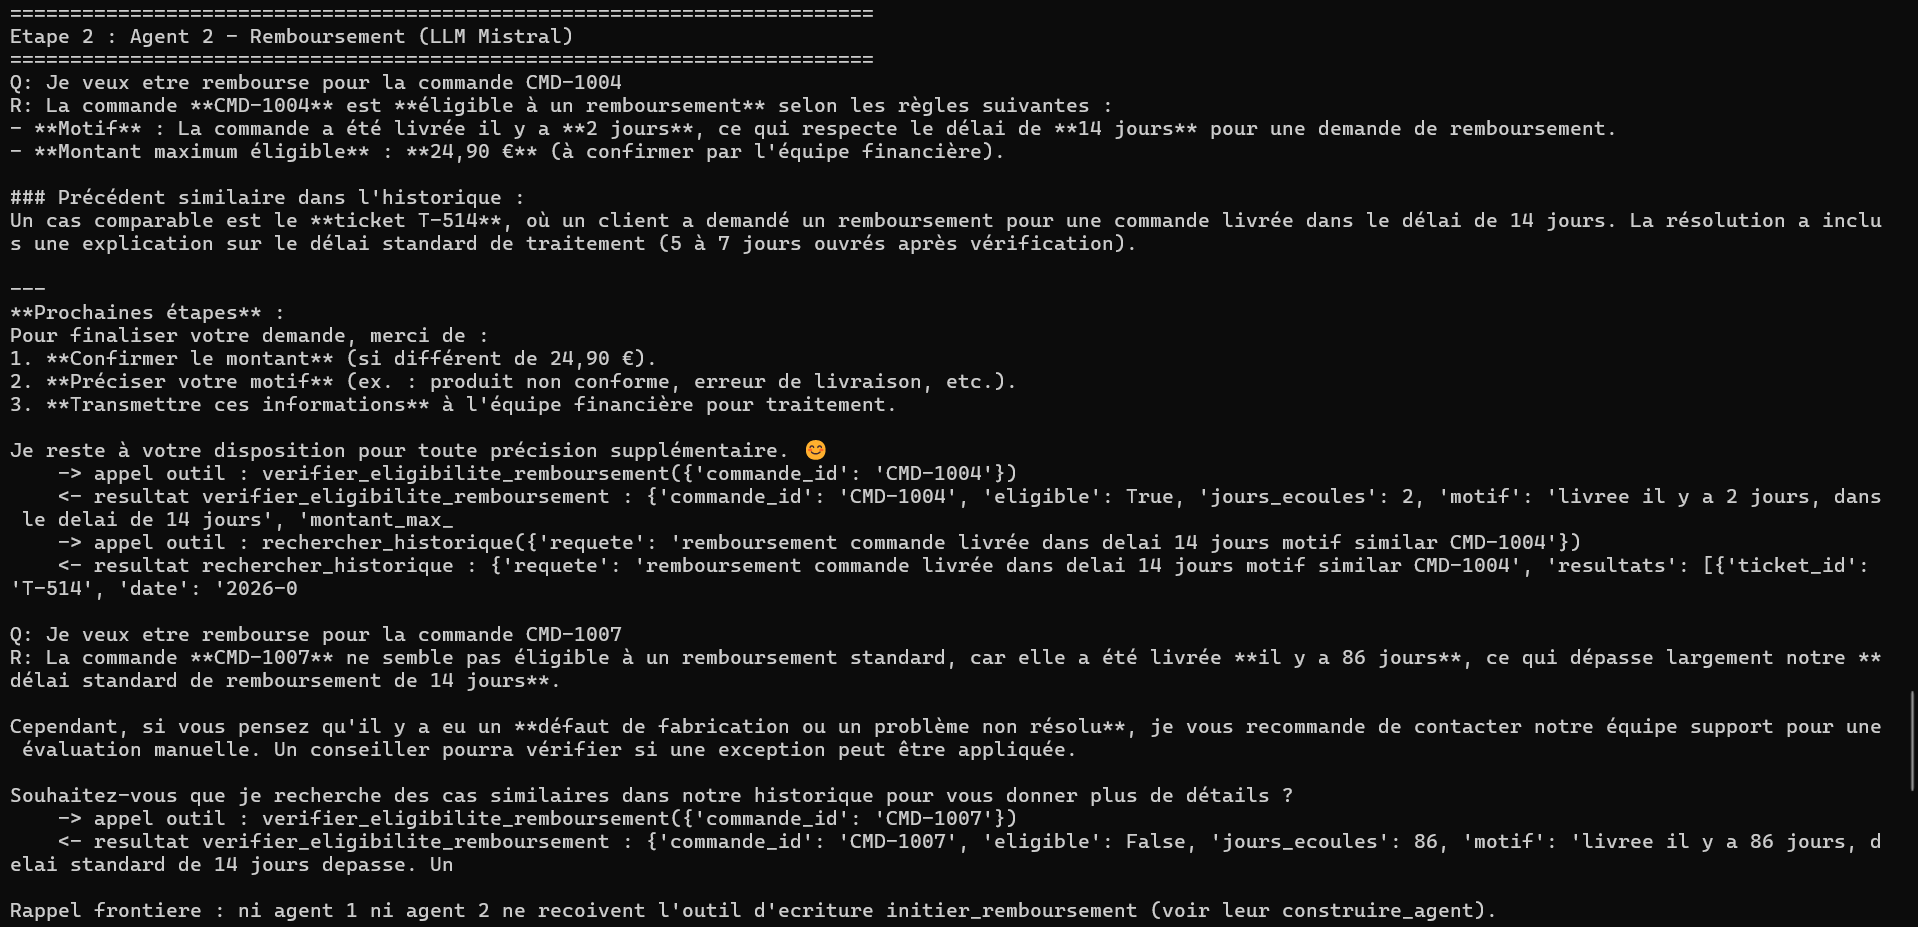

In [21]:
from IPython.display import Image, display
display(Image(filename="../agent2.png"))

<h2 style="color:blue;"> test Agent 2

une commande qui peut être éligible ;

une commande hors délai ;

une commande non livrée ;

une commande inexistante

In [12]:
for q in [
    "Je veux etre rembourse pour la commande CMD-1004",
    "Je veux etre rembourse pour la commande CMD-1007",
    "Je veux etre rembourse pour la commande CMD-1011",
    "Je veux etre rembourse pour la commande CMD-9999",
]:
    res = A2.repondre(ctx, q)
    print("Q:", q)
    print("R:", res["diagnostic"]["reponse"])
    print()

Q: Je veux etre rembourse pour la commande CMD-1004
R: La commande **CMD-1004** est **éligible à un remboursement** selon les critères suivants :
- **Motif** : La commande a été livrée il y a **2 jours**, ce qui respecte le délai de **14 jours** pour une demande de remboursement.
- **Montant maximal** : Le remboursement peut couvrir jusqu’à **24,90 €**.

### Précédent similaire dans l'historique :
Dans le ticket **[T-514](https://support.klaro.com/tickets/T-514)**, un client avait demandé un remboursement pour une commande livrée dans les 14 jours. La résolution avait confirmé l'éligibilité, avec une explication sur le délai standard de traitement (5 à 7 jours ouvrés après vérification).

---
**Prochaines étapes** :
- Le remboursement doit être **validé manuellement** par un membre de l'équipe support.
- Le délai de traitement est généralement de **5 à 7 jours ouvrés** après validation de votre demande.
- Si vous avez des justificatifs (photo du produit, preuve de défaut, etc.), merci 

CMD-1004 → éligible
- livrée le 2026-03-13
- date de référence : 2026-03-15
- seulement 2 jours écoulés
- donc dans le délai de 14 jours

CMD-1007 → hors délai
- livrée le 2025-12-19
- largement plus de 14 jours avant la date de référence

CMD-1011 → non livrée
- statut : expediee
- donc pas encore livrée
- elle n’est pas éligible au remboursement standard

CMD-9999 → commande inexistante
- elle n’existe pas dans commandes.csv

## Agent 3 - Pre-triage des messages entrants

Mesurez le taux d'accord et la part de propositions validees sans
modification (biais d'automatisation). TODO dans
`src/agent/agent3_pretriage.py` : `classifier_message`.

`C.LIMITE_MESSAGES_PRETRIAGE` (dans `config.py`) borne le nombre de messages
traites pour economiser des appels API pendant le developpement.

| Fonction | À quoi elle sert |
|---|---|
| `pretrier()` | Parcourt les messages entrants et appelle `classifier_message()` pour chaque message. Elle construit ensuite le tableau de pré-triage. |
| `classifier_message()` | Prend le texte d’un message client et demande à Mistral de proposer une catégorie, une confiance et une justification. |
| `construire_modele_llm()` | Récupère le modèle Mistral utilisé par l’Agent 3. |
| `modele.invoke()` | Envoie le prompt au modèle Mistral et récupère sa réponse. |
| `_parser_reponse_json()` | Lit la réponse de Mistral et récupère proprement les champs `categorie`, `confiance` et `justification`. |
| `simuler_validation()` | Simule la validation d’un conseiller :qui peut garder ou corriger la proposition IA |
| `taux()` | Calcule les indicateurs finaux : taux d’accord, part validée sans modification et alerte de biais d’automatisation. |

In [10]:
pretri = A3.pretrier(messages)
valide = A3.simuler_validation(pretri)
A3.taux(valide)

{'taux_accord_global': 0.917,
 'taux_accord_ambigus': 1.0,
 'part_validee_sans_modification': 0.917,
 'alerte_biais_automatisation': True}

## Résultats de l’Agent 3

- `taux_accord_global = 0.917`
  → environ 91,7 % des propositions correspondent à la décision finale.

- `taux_accord_ambigus = 1.0`
  → les cas ambigus évalués ont tous été correctement traités.

- `part_validee_sans_modification = 0.917`
  → environ 91,7 % des propositions ont été conservées sans correction.

- `alerte_biais_automatisation = True`
  → le taux de validation sans modification est très élevé, ce qui montre un risque que le conseiller fasse trop confiance aux propositions de l’IA.

même sur `M-006` où la catégorie proposée est incorrecte il a mis pour le  score de confiance 0.95

<h2 style="color:blue;">Affichage des 12 messages pré-triés</h2>

In [25]:
pretri.head(12)

,message_id,date,texte,_categorie_vraie,_ambigu,cat_proposee,confiance,justification
0,M-001,2026-03-14,Bonjour ma commande CMD-1013 devait arriver le...,livraison,0,livraison,0.95,Le message mentionne explicitement une command...
1,M-002,2026-03-14,Je souhaite retourner mon aspirateur il ne me ...,retour_remboursement,0,retour_remboursement,0.95,Le message mentionne explicitement le retour d...
2,M-003,2026-03-14,Impossible de me connecter a mon compte le mot...,compte,0,compte,0.95,Le message mentionne explicitement un problème...
3,M-004,2026-03-13,Est ce que la chaise de bureau supporte plus d...,produit,0,produit,0.95,Le message porte sur une caractéristique techn...
4,M-005,2026-03-13,J'ai ete debite deux fois pour la meme command...,paiement,0,paiement,0.95,Le message mentionne explicitement un problème...
5,M-006,2026-03-13,Bonjour je voulais juste vous remercier pour l...,autre,0,livraison,0.95,Le message mentionne explicitement la rapidité...
6,M-007,2026-03-13,Toujours rien recu et le suivi ne bouge plus d...,livraison,0,livraison,0.95,Le message mentionne explicitement un problème...
7,M-008,2026-03-12,Le robot patissier fuit de partout des la prem...,retour_remboursement,0,produit,0.95,Le message mentionne un dysfonctionnement spéc...
8,M-009,2026-03-12,Comment supprimer definitivement mon compte et...,compte,0,compte,1.00,Le message mentionne explicitement la suppress...
9,M-010,2026-03-12,Peut on payer en plusieurs fois pour un panier...,paiement,0,paiement,1.00,Le message aborde explicitement une question l...


## erreur M-006/M-008	

| Point vérifié | Problème observé | Statut |
|---|---|---|
| Agent 3 - classification | Un message peut être mal classé même avec une confiance élevée. |  Non cohérent |



## Agent 4 - Autonomie sous contrainte

Propose puis, seulement si un humain approuve, execute un remboursement
automatise dans les cas les plus clairs (middleware human-in-the-loop). TODO
dans `src/agent/agent4_autonomie.py` : `construire_agent`.

Trois cas : un cas approuve, un cas rejete, un cas au-dessus du plafond
automatisable (refuse par l'outil quoi qu'il arrive).

In [10]:
print(A4.executer_agent4(ctx, "CMD-1004", {"type": "approve"})["diagnostic"]["reponse"])
print(A4.executer_agent4(ctx, "CMD-1035", {"type": "reject", "message": "non valide par le conseiller"})["diagnostic"]["reponse"])
print(A4.executer_agent4(ctx, "CMD-1009", {"type": "approve"})["diagnostic"]["reponse"])

La commande **CMD-1004** est **éligible** au remboursement pour un montant maximal de **24,90 EUR**, car elle a été livrée il y a **2 jours** (dans le délai de 14 jours).

### Proposition :
Le montant étant **inférieur ou égal à 60,00 EUR**, je peux **initier le processus de remboursement** pour validation humaine explicite.
Souhaitez-vous que je lance cette étape ?
La commande **CMD-1035** est **éligible** au remboursement standard pour les raisons suivantes :
- **Motif** : Livrée il y a **1 jour**, dans le délai de **14 jours** autorisé.
- **Montant maximal éligible** : **59,90 EUR** (inférieur au seuil de 60,0 EUR).

### Proposition :
Je peux **initier le processus de remboursement** pour ce montant, sous réserve de validation humaine explicite. Souhaitez-vous que je procède à cette étape ?
La commande **CMD-1009** est **éligible** au remboursement pour les raisons suivantes :
- **Motif** : Livrée il y a **13 jours** (dans le délai de 14 jours).
- **Montant maximal éligible** : **49

## Etape 3 - Evaluation croisee (en dehors de ce notebook)

Chacun teste et evalue les 2 agents developpes par son binome (pas les
siens) et redige un rapport court. Voir le brief, etape 3.

## Etape 4 - Integrer et decider (en binome)

Mettez en commun les 4 agents, verifiez qu'ils s'articulent sans se
contredire, et redigez une decision de deploiement commune a partir des deux
rapports d'evaluation croisee. Voir le brief, etape 4.